In [ ]:
import pandas as pd
# Load
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv"
df = pd.read_csv(url, sep=";")



In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# The "Statistics" (Mean, Max, Min)
# This tells you the 'range' of your customers
print("\n--- Numerical Summary ---")
print(df[['Income', 'Year_Birth', 'Recency']].describe())


--- Numerical Summary ---
              Income   Year_Birth      Recency
count    2216.000000  2240.000000  2240.000000
mean    52247.251354  1968.805804    49.109375
std     25173.076661    11.984069    28.962453
min      1730.000000  1893.000000     0.000000
25%     35303.000000  1959.000000    24.000000
50%     51381.500000  1970.000000    49.000000
75%     68522.000000  1977.000000    74.000000
max    666666.000000  1996.000000    99.000000


In [ ]:
# The "Value Counts"
# This tells you the 'diversity' of your customers
print("\n--- Education Levels in the Store ---")
print(df['Education'].value_counts())


--- Education Levels in the Store ---
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [ ]:
# Check rows, columns, and missing data
print(df.shape)
print(df.isnull().sum()) # Found 24 missing Income values

(2240, 29)
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [ ]:
# --- STEP 2: PREPROCESSING ---

# Fill Missing Income with the Median
# We use median because it's not affected by those $600k outliers
median_income = df['Income'].median()
df['Income'] = df['Income'].fillna(median_income)
print(f"Filled missing values with: ${median_income}")

# Create the Target Label (The 'Supervised' part)
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# Define High-Value as the top 30% of spenders
threshold = df['TotalSpending'].quantile(0.7)
df['Profile'] = (df['TotalSpending'] > threshold).astype(int)

# Simplify 'Education' (Encoding)
# Let's map them to a simple numeric scale
edu_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_Level'] = df['Education'].map(edu_map)

print("\n--- Preprocessed Data (First 5 Rows) ---")
print(df[['Education', 'Education_Level', 'Income', 'Profile']].head())

Filled missing values with: $51381.5

--- Preprocessed Data (First 5 Rows) ---
    Education  Education_Level   Income  Profile
0  Graduation                2  58138.0        1
1  Graduation                2  46344.0        0
2  Graduation                2  71613.0        0
3  Graduation                2  26646.0        0
4         PhD                4  58293.0        0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define X (Features/Clues) and y (Target/Label)
# We use the features that describe the 'Person'
features = ['Education_Level', 'Income', 'Kidhome', 'Teenhome', 'Recency']
X = df[features]
y = df['Profile']

# The Split
# random_state=42 ensures that if you run this again, you get the same 'random' split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Scaling (The 'Leveling' Step)
# Income is in the 50,000s, but Kids is 0-2.
# We 'Scale' them so the model treats them fairly.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Scaled Data (First row of Training) ---")
print(X_train_scaled[0])

Training samples: 1792
Testing samples: 448

--- Scaled Data (First row of Training) ---
[-0.45680457 -1.35137271 -0.83792139 -0.92556693  0.01987908]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Model
# n_estimators=100 means we are building a forest of 100 trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. THE SUPERVISED STEP: Training
# We give the model the features AND the answers
model.fit(X_train_scaled, y_train)

print("Model Training Complete!")

# 3. Check the 'Internal' Logic (Feature Importance)
# This shows what the model decided was the most important 'clue'
import pandas as pd
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("\n--- What the Model Learned (Feature Importance) ---")
print(importance)

Model Training Complete!

--- What the Model Learned (Feature Importance) ---
Income             0.639414
Recency            0.148492
Kidhome            0.126294
Teenhome           0.049297
Education_Level    0.036503
dtype: float64


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Ask the model to 'guess' the profiles for the test set
y_pred = model.predict(X_test_scaled)

# 2. Compare the guesses (y_pred) to the actual truth (y_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nFinal Accuracy: {accuracy:.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Standard', 'High-Value']))


Final Accuracy: 0.87

Detailed Performance Report:
              precision    recall  f1-score   support

    Standard       0.91      0.89      0.90       300
  High-Value       0.79      0.83      0.81       148

    accuracy                           0.87       448
   macro avg       0.85      0.86      0.86       448
weighted avg       0.87      0.87      0.87       448



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- STEP 1: Simple Supervised Learning (Logistic Regression) ---
# This is the 'Baseline' model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

# --- STEP 2: Complex Supervised Learning (Random Forest) ---
# This is the 'Advanced' model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# --- STEP 3: Compare the Results ---
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score (High-Value)'],
    'Logistic Regression (Simple)': [
        accuracy_score(y_test, log_pred),
        f1_score(y_test, log_pred)
    ],
    'Random Forest (Complex)': [
        accuracy_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
})

print("--- Model Comparison ---")
print(results.to_string(index=False))

--- Model Comparison ---
               Metric  Logistic Regression (Simple)  Random Forest (Complex)
             Accuracy                      0.857143                 0.870536
F1-Score (High-Value)                      0.773050                 0.809211


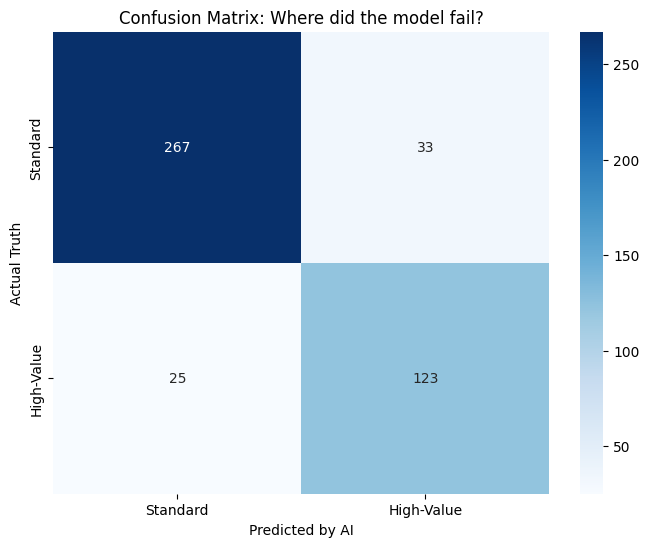

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
# 1. Generate the Confusion Matrix
# Row = Actual Label, Column = Predicted Label
cm = confusion_matrix(y_test, rf_pred)

# 2. Visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Standard', 'High-Value'],
            yticklabels=['Standard', 'High-Value'])

plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.title('Confusion Matrix: Where did the model fail?')
plt.show()

--- How the Models 'Think' ---
        Feature  LogReg_Weight  RF_Importance
         Income       2.286568       0.639414
        Recency       0.084368       0.148492
        Kidhome      -1.080524       0.126294
       Teenhome      -0.551863       0.049297
Education_Level       0.151164       0.036503


/tmp/ipykernel_16846/4052074499.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RF_Importance', y='Feature', data=comparison_df, palette='viridis')


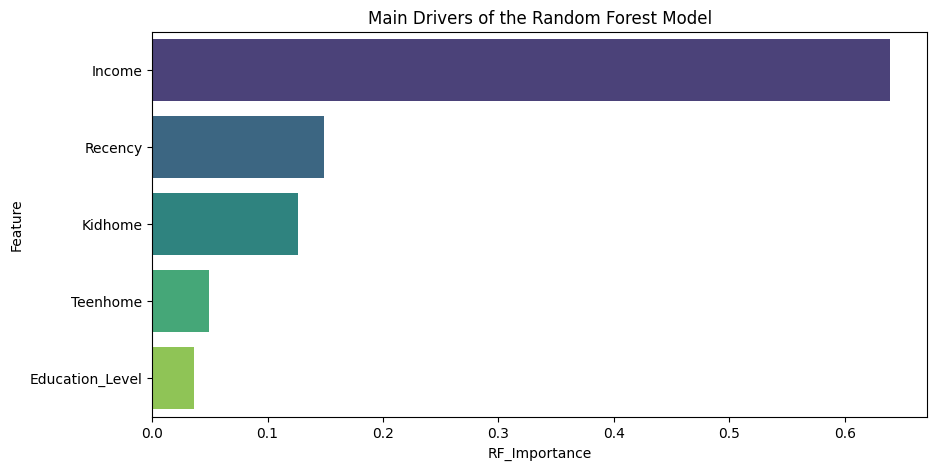

In [ ]:
# 1. Get Logistic Regression Coefficients (The 'Weight' of each feature)
log_importance = log_model.coef_[0]

# 2. Get Random Forest Importance (The 'Power' of each feature)
rf_importance = rf_model.feature_importances_

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Feature': features,
    'LogReg_Weight': log_importance,
    'RF_Importance': rf_importance
}).sort_values(by='RF_Importance', ascending=False)

print("--- How the Models 'Think' ---")
print(comparison_df.to_string(index=False))

# 3. Visualize the 'Winner' (Random Forest Logic)
plt.figure(figsize=(10, 5))
sns.barplot(x='RF_Importance', y='Feature', data=comparison_df, palette='viridis')
plt.title('Main Drivers of the Random Forest Model')
plt.show()

In [ ]:
import joblib

# Save the model and the scaler to files
joblib.dump(rf_model, 'supermarket_model.pkl')
joblib.dump(scaler, 'data_scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [ ]:
# Install Gradio if you haven't already
#

import gradio as gr
import joblib
import numpy as np

# Load the saved tools
model = joblib.load('supermarket_model.pkl')
scaler = joblib.load('data_scaler.pkl')

def predict_customer_profile(income, kids, teens, recency, education):
    # 1. Map education to our numeric scale
    edu_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
    edu_val = edu_map[education]

    # 2. Create the input array
    # Order must match: ['Education_Level', 'Income', 'Kidhome', 'Teenhome', 'Recency']
    input_data = np.array([[edu_val, income, kids, teens, recency]])

    # 3. Scale and Predict
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]

    # 4. Format the result
    label = "💎 High-Value Customer" if prediction == 1 else "🛒 Standard Customer"
    confidence = f"{probability[prediction]*100:.2f}%"

    return label, confidence

# Build the Interface
interface = gr.Interface(
    fn=predict_customer_profile,
    inputs=[
        gr.Number(label="Annual Income ($)", value=50000),
        gr.Slider(0, 3, step=1, label="Number of Kids"),
        gr.Slider(0, 3, step=1, label="Number of Teens"),
        gr.Slider(0, 100, label="Recency (Days since last visit)"),
        gr.Dropdown(['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'], label="Education Level")
    ],
    outputs=[
        gr.Textbox(label="Predicted Profile"),
        gr.Textbox(label="AI Confidence")
    ],
    title="Supermarket Customer Classifier",
    description="Enter customer demographics to see if the AI classifies them as a High-Value spender."
)

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4d9cc1126124301969.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

| Scenario   | Income | Kids/Teens | Recency | Education  | Goal                                       |
|------------|--------|------------|--------|------------|--------------------------------------------|
| VIP        | 90k+   | 0 / 0      | under 10| PhD/Master | Verify High-Value detection                |
| Family     | 40k    | 2 / 0      | 30     | Basic      | Verify Standard detection                  |
| Inactive   | 120k   | 0 / 0      | 90+    | Graduation | Check if Recency overrides Income          |
| Borderline | 65k    | 1 / 0      | 15     | Master     | See how the model handles ambiguity        |

| Scenario   | Income | Kids/Teens | Recency | Education  | Goal                                       |
|------------|--------|------------|--------|------------|--------------------------------------------|
| VIP        | 90k+   | 0 / 0      | under 10| PhD/Master | Verify High-Value detection                |
| Family     | 40k    | 2 / 0      | 30     | Basic      | Verify Standard detection                  |
| Inactive   | 120k   | 0 / 0      | 90+    | Graduation | Check if Recency overrides Income          |
| Borderline | 65k    | 1 / 0      | 15     | Master     | See how the model handles ambiguity        |